In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from src.preprocessing import load_data, retrieve_airport_data
from src.forecast import NaiveSeasonalWithDrift, TripleExponentialSmoothing, evaluate_forecast, make_rolling_splits

In [3]:
df = load_data("data/tsa-throughput-data-complete.csv")
ord_daily = retrieve_airport_data(df, "ORD", "D")

In [4]:
ord_daily

,datetime,total_passenger_throughput,day
0,2022-01-02,57237,2
1,2022-01-03,61147,3
2,2022-01-04,50709,4
3,2022-01-05,46234,5
4,2022-01-06,48520,6
...,...,...,...
1454,2025-12-26,97925,360
1455,2025-12-27,96825,361
1456,2025-12-28,99596,362
1457,2025-12-29,95498,363


In [24]:
ord_daily = ord_daily[ord_daily.datetime <= '2025-06-23']
splits = make_rolling_splits(ord_daily, date_col='datetime', n_splits=5, step_days=90)

Split 1: train → 2024-03-30 | test 2024-03-31 → 2024-06-28 (90 days)
Split 2: train → 2024-06-28 | test 2024-06-29 → 2024-09-26 (90 days)
Split 3: train → 2024-09-26 | test 2024-09-27 → 2024-12-25 (90 days)
Split 4: train → 2024-12-25 | test 2024-12-26 → 2025-03-25 (90 days)
Split 5: train → 2025-03-25 | test 2025-03-26 → 2025-06-23 (90 days)


In [5]:
from src.harmonic_model import fourier_features, time_index_feature

In [ ]:
# Creat Fourier features and time index feature for daily data
ord_daily_ff = fourier_features(ord_daily['day'], m=365, k=10)
ord_daily_ti = time_index_feature(ord_daily['day'])
ord_daily_X = np.column_stack([ord_daily_ff, ord_daily_ti])

For practice, let's run the model on last split

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [ ]:
model = LinearRegression()
X_train = ord_daily_X[splits[-1][0]]
X_test  = ord_daily_X[splits[-1][1]]
y_train = ord_daily.iloc[splits[-1][0]].total_passenger_throughput
y_test  = ord_daily.iloc[splits[-1][1]].total_passenger_throughput
model.fit(X_train, y_train)
predicted = model.predict(X_test)
metrics = {}
metrics['mse'] = mean_squared_error(y_test, predicted)
metrics['mape'] = mean_squared_error(y_test, predicted)

Print metrics and plot the fit

100.50027049604437
100.50027049604437


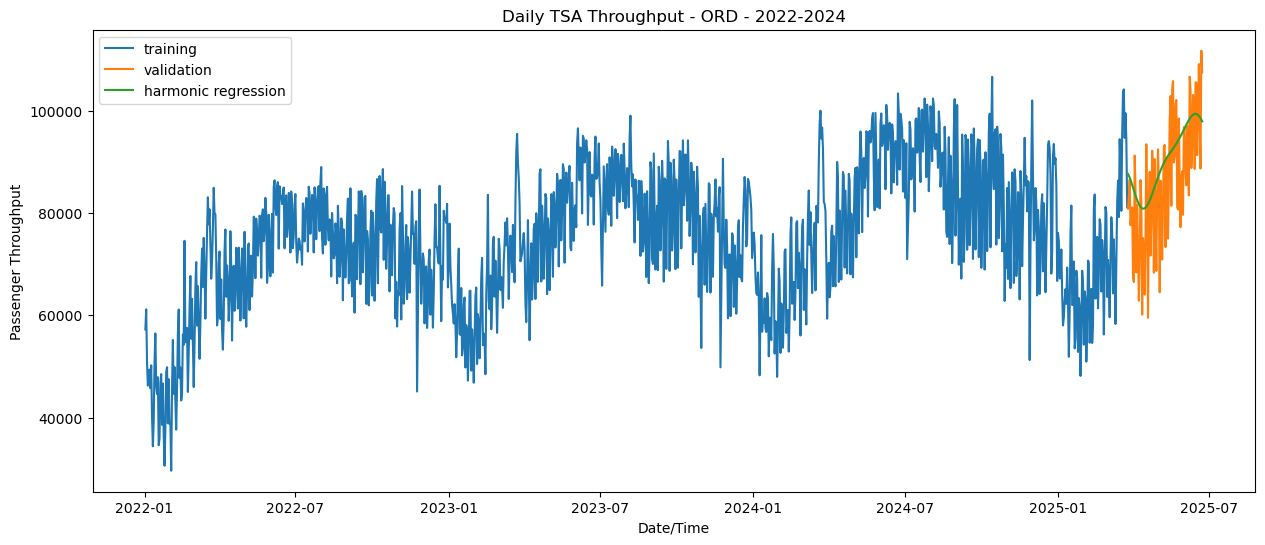

In [51]:
print(metrics['mse'] / 1e6) 
print(metrics['mape'] / 1e6)
plt.figure(figsize=(15, 6))
plt.plot(ord_daily.iloc[splits[-1][0]].datetime, y_train, label='training')
plt.plot(ord_daily.iloc[splits[-1][1]].datetime, y_test, label='validation')
plt.plot(ord_daily.iloc[splits[-1][1]].datetime, predicted, label='harmonic regression')
plt.title('Daily TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

Now we can apply the harmonic regression in all the splits and compare


Minimum metrics:
  MSE:  (18, 139,345,936)
  MAPE: (18, 0.12%)
  RMSE: (18, 11,796)


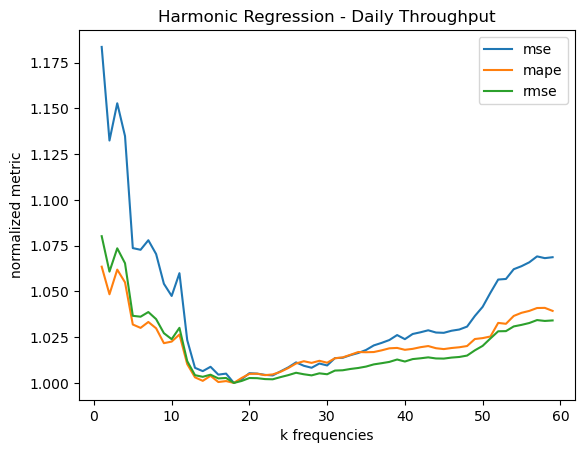

In [94]:
results = []

for k_freq in range(1, 60):
    # Determine Fourier features for the given number of frequencies
    ord_daily_X = fourier_features(ord_daily['day'], m=365, k=k_freq)
    
    k_metrics = []

    for i, (train_idx, test_idx) in enumerate(splits, start = 1):
        X_train = ord_daily_X[train_idx]
        X_test  = ord_daily_X[test_idx]
        y_train = ord_daily.iloc[train_idx].total_passenger_throughput
        y_test  = ord_daily.iloc[test_idx].total_passenger_throughput

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = {}
        metrics['split'] = i
        metrics['mse'] = mean_squared_error(y_test, y_pred)
        metrics['mape'] = mean_absolute_percentage_error(y_test, y_pred)
        metrics['rmse'] = np.sqrt(metrics['mse'])
        k_metrics.append(metrics)
    
    metrics_df = pd.DataFrame(k_metrics).set_index('split')
    mean_metrics = {}
    mean_metrics['k_freq'] = k_freq
    mean_metrics['mse']  = metrics_df['mse'].mean()
    mean_metrics['mape'] = metrics_df['mape'].mean()
    mean_metrics['rmse'] = metrics_df['rmse'].mean()
    results.append(mean_metrics)

results_df = pd.DataFrame(results).set_index('k_freq')

print(f"\nMinimum metrics:")
print(f"  MSE:  ({results_df['mse'].idxmin()}, {results_df['mse'].min():,.0f})")
print(f"  MAPE: ({results_df['mape'].idxmin()}, {results_df['mape'].min():.2f}%)")
print(f"  RMSE: ({results_df['rmse'].idxmin()}, {results_df['rmse'].min():,.0f})")

# Rescale all metrics based on their minumum value
results_df = results_df / results_df.min()
results_df.plot()
plt.title('Harmonic Regression - Daily Throughput')
plt.xlabel('k frequencies')
plt.ylabel('normalized metric')
plt.legend()
plt.show()



Minimum metrics:
  MSE:  (23, 79,097,524)
  MAPE: (24, 0.09%)
  RMSE: (23, 8,810)


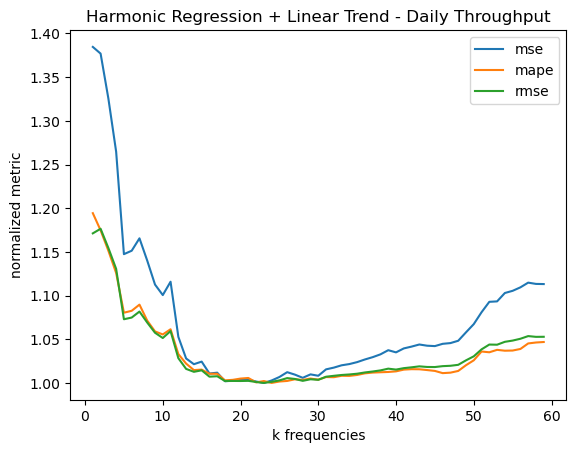

In [96]:
# We repeat the same process with the linear trend as well
results = []

for k_freq in range(1, 60):
    # Determine Fourier features for the given number of frequencies
    ord_daily_ff = fourier_features(ord_daily['day'], m=365, k=k_freq)
    ord_daily_ti = time_index_feature(ord_daily['day'])
    ord_daily_X = np.column_stack([ord_daily_ff, ord_daily_ti])
    
    k_metrics = []

    for i, (train_idx, test_idx) in enumerate(splits, start = 1):
        X_train = ord_daily_X[train_idx]
        X_test  = ord_daily_X[test_idx]
        y_train = ord_daily.iloc[train_idx].total_passenger_throughput
        y_test  = ord_daily.iloc[test_idx].total_passenger_throughput

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = {}
        metrics['split'] = i
        metrics['mse'] = mean_squared_error(y_test, y_pred)
        metrics['mape'] = mean_absolute_percentage_error(y_test, y_pred)
        metrics['rmse'] = np.sqrt(metrics['mse'])
        k_metrics.append(metrics)
    
    metrics_df = pd.DataFrame(k_metrics).set_index('split')
    mean_metrics = {}
    mean_metrics['k_freq'] = k_freq
    mean_metrics['mse']  = metrics_df['mse'].mean()
    mean_metrics['mape'] = metrics_df['mape'].mean()
    mean_metrics['rmse'] = metrics_df['rmse'].mean()
    results.append(mean_metrics)

results_df = pd.DataFrame(results).set_index('k_freq')

print(f"\nMinimum metrics:")
print(f"  MSE:  ({results_df['mse'].idxmin()}, {results_df['mse'].min():,.0f})")
print(f"  MAPE: ({results_df['mape'].idxmin()}, {results_df['mape'].min():.2f}%)")
print(f"  RMSE: ({results_df['rmse'].idxmin()}, {results_df['rmse'].min():,.0f})")

# Rescale all metrics based on their minumum value
results_df = results_df / results_df.min()
results_df.plot()
plt.title('Harmonic Regression + Linear Trend - Daily Throughput')
plt.xlabel('k frequencies')
plt.ylabel('normalized metric')
plt.legend()
plt.show()

Now with that process completed, we are ready to perform the auto SARIMA with weekly seasonality

In [97]:
import pmdarima as pm

In [99]:
# Like before, we first test it out on just one split
ord_daily_X = fourier_features(ord_daily['day'], m=365, k=18)

X_train = ord_daily_X[splits[0][0]]
X_test  = ord_daily_X[splits[0][1]]
y_train = ord_daily.iloc[splits[0][0]].total_passenger_throughput
y_test  = ord_daily.iloc[splits[0][1]].total_passenger_throughput

arima_model = pm.auto_arima(
    y_train,
    X=X_train,
    seasonal=True, m=7,
    d=1, D=0,
    # start_p=0, max_p=1,
    # start_q=0, max_q=1,
    # start_P=0, max_P=1,
    # start_Q=0, max_Q=1,
    stepwise=True,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=16516.956, Time=219.82 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=17333.498, Time=0.60 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=16856.580, Time=88.77 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=16800.379, Time=146.52 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=22000.712, Time=0.63 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=16711.257, Time=96.32 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=16619.793, Time=188.92 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=inf, Time=284.26 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=16517.340, Time=264.22 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=16811.825, Time=13.61 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=16640.669, Time=128.55 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=16559.234, Time=232.64 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=259.51 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=16549.225, Time=237.22 sec
 ARIMA(2,1

KeyboardInterrupt: 

Take the resulting best ARIMA.
First fit it on all folds and see what we get.
Then do the same analysis as earlier but with this ARIMA instead of OLS
Then maybe repeat the same thing with intercept and see what wins...

In [100]:
# The best fitting ARIMA was (4,1,2)(1,0,1)[7] without intercept
# Now we cross-validate along every fold and compare with the baseline models

# Determine Fourier features for the optimized number of frequencies
ord_daily_X = fourier_features(ord_daily['day'], m=365, k=18)

results = []

for i, (train_idx, test_idx) in enumerate(splits, start = 1):
    X_train = ord_daily_X[train_idx]
    X_test  = ord_daily_X[test_idx]
    y_train = ord_daily.iloc[train_idx].total_passenger_throughput
    y_test  = ord_daily.iloc[test_idx].total_passenger_throughput

    # Establish baseline models and Harmonic model to compare
    nswd_year_model = NaiveSeasonalWithDrift(season_length=365)
    nswd_week_model = NaiveSeasonalWithDrift(season_length=7)
    exps_year_model = TripleExponentialSmoothing(season_length=365)
    exps_week_model = TripleExponentialSmoothing(season_length=7)
    harmonic_model = pm.ARIMA(order=(4,1,2), seasonal_order=(1,0,1,7), with_intercept=False)

    # Fit models
    nswd_year_model.fit(y_train)
    nswd_week_model.fit(y_train)
    exps_year_model.fit(y_train)
    exps_week_model.fit(y_train)
    harmonic_model.fit(y_train, X_train)

    # Evaluate models
    nwsd_year_pred = nswd_year_model.forecast(h=len(y_test))
    nwsd_week_pred = nswd_week_model.forecast(h=len(y_test))
    exps_year_pred = exps_year_model.forecast(h=len(y_test))
    exps_week_pred = exps_week_model.forecast(h=len(y_test))
    harmonic_pred = harmonic_model.predict(n_periods=len(y_test), X=X_test)

    metrics = {}
    metrics['model'] = 'nswd_year'
    metrics['split'] = i
    metrics['mse'] = mean_squared_error(y_test, nwsd_year_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, nwsd_year_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    results.append(metrics)

    metrics = {}
    metrics['model'] = 'nswd_week'
    metrics['split'] = i
    metrics['mse'] = mean_squared_error(y_test, nwsd_week_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, nwsd_week_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    results.append(metrics)

    metrics = {}
    metrics['model'] = 'exps_year'
    metrics['split'] = i
    metrics['mse'] = mean_squared_error(y_test, exps_year_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, exps_year_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    results.append(metrics)

    metrics = {}
    metrics['model'] = 'exps_week'
    metrics['split'] = i
    metrics['mse'] = mean_squared_error(y_test, exps_week_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, exps_week_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    results.append(metrics)

    metrics = {}
    metrics['model'] = 'harmonic'
    metrics['split'] = i
    metrics['mse'] = mean_squared_error(y_test, harmonic_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, harmonic_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    results.append(metrics)

    print(f"Finished split {i}")

cv_means = pd.DataFrame(results).groupby(by=["model"])[["mse", "mape", "rmse"]].mean()

print(f"\nCV Results:")
# print(f"  MSE: {cv_means['mse']:,.0f}")
# print(f"  MAPE: {cv_means['mape']:.2f}%")
# print(f"  RMSE: {cv_means['rmse']:,.0f}")
print(cv_means)

/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Finished split 1


/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

Finished split 2


/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Finished split 3


/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Finished split 4


/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished split 5

CV Results:
                    mse      mape          rmse
model                                          
exps_week  1.869880e+08  0.146456  13449.021787
exps_year  1.316201e+08  0.119936  11433.884702
harmonic   6.874194e+07  0.078303   7983.442786
nswd_week  1.658911e+10  0.733121  73251.973408
nswd_year  3.342611e+08  0.188229  17904.882424
